In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import joblib
import json

In [2]:
# ==================== 1. 数据准备 ====================
df = pd.read_csv('parameter.csv')

In [3]:
# ==================== 2. 特征工程（与能耗模型对齐）====================

# 2.1 条件参数激活：根据 type 消除物理无效参数
# type=1(水平): hori_rot 有效, ver_rot 无效
# type=2(垂直): ver_rot 有效, hori_rot 无效  
# type=3(混合): 两者均有效
df['hori_rot_eff'] = df['hori_rot'] * df['type'].isin([1, 3]).astype(int)
df['ver_rot_eff'] = df['ver_rot'] * df['type'].isin([2, 3]).astype(int)

# 关键：删除原始旋转角度列，避免模型学到条件无关的虚假相关性
df = df.drop(columns=['hori_rot', 'ver_rot'])

# 2.2 U值映射（与能耗模型一致）
u_value_map = {1: 3.54, 2: 1.84, 3: 2.59, 4: 1.71} 
df['glazing_u_value'] = df['win'].map(u_value_map)

# 2.3 交互特征（改用 _eff 版本，确保无效路径被切断）
df['thermal_load_index'] = (df['wwr'] / 100) * df['glazing_u_value']
df['wwr_ver_rot'] = df['wwr'] * df['ver_rot_eff']   # ← 改用 ver_rot_eff
df['wwr_int'] = df['wwr'] * df['int']
df['shade_balance'] = df['hor_depth'] / (df['wwr'])

# 如有其他涉及 hori_rot/ver_rot 的交互特征，同理改用 _eff 版本

# ==================== 3. 独热编码（后续流程完全不变）====================
categorical_cols = ['type', 'mat', 'win']
df_encoded = pd.get_dummies(df, columns=categorical_cols)
X = df_encoded.drop(columns=['Energy', 'sDGP'])
y_sDGP = df_encoded['sDGP']


# ==================== 4. 划分测试集 ====================
X_train, X_test, y_train_u, y_test_u = train_test_split(
    X, y_sDGP, test_size=0.2, random_state=42
)


# ==================== 5. 训练最终模型（使用最优参数）====================
params_sDGP = {
    'colsample_bytree': 0.9,
    'learning_rate': 0.03,
    'max_depth': 6,
    'n_estimators': 1100,
    'reg_alpha': 1.0,
    'reg_lambda': 5.0,
    'subsample': 0.7,
    'random_state':311,
    'gamma': 0.2,
    'min_child_weight': 2
}

print("\n正在训练 sDGP 模型...")
model_u = xgb.XGBRegressor(**params_sDGP)
model_u.fit(X_train, y_train_u)


# ==================== 6. 验证评估 ====================
pred_u = model_u.predict(X_test)

r2_u = r2_score(y_test_u, pred_u)
rmse_u = np.sqrt(mean_squared_error(y_test_u, pred_u))
mae_u = mean_absolute_error(y_test_u, pred_u)

print(f"\nsDA 验证结果: R²={r2_u:.3f}, RMSE={rmse_u:.3f}")


正在训练 sDGP 模型...

sDA 验证结果: R²=0.938, RMSE=5.848


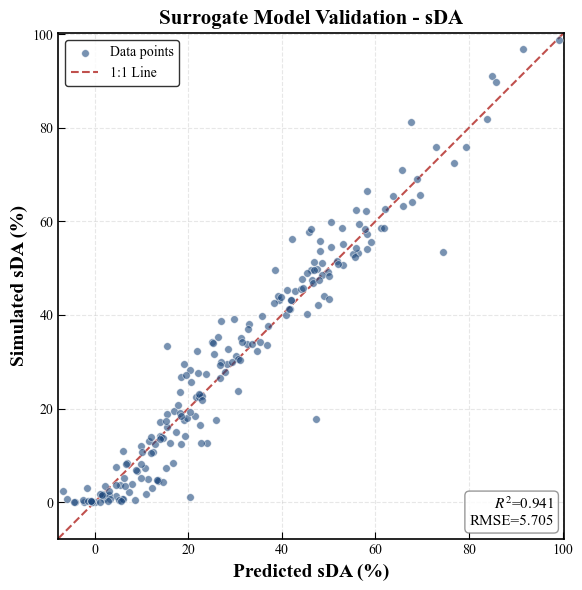

In [4]:
# ==================== 7. SCI 标准验证图 ====================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(7, 6))

color_u = '#1f497d'
line_color = '#c0504d'

min_u, max_u = min(min(pred_u), min(y_test_u))-1, max(max(pred_u), max(y_test_u))+1
ax.scatter(pred_u, y_test_u, s=30, c=color_u, alpha=0.6, edgecolors='white', linewidth=0.5, zorder=3)
ax.plot([min_u, max_u], [min_u, max_u], '--', color=line_color, linewidth=1.5, zorder=2)
ax.set_xlabel('Predicted sDA (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Simulated sDA (%)', fontsize=14, fontweight='bold')
ax.set_title('Surrogate Model Validation - sDA', fontsize=15, fontweight='bold')
ax.set_xlim(min_u, max_u)
ax.set_ylim(min_u, max_u)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend(['Data points', '1:1 Line'], loc='upper left', frameon=True, edgecolor='black')
ax.text(0.98, 0.02, f'$R^2$={r2_u:.3f}\nRMSE={rmse_u:.3f}', transform=ax.transAxes,
        fontsize=11, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('s_XGBoost_sDA_Validation.png', dpi=600, bbox_inches='tight')
plt.show()

In [5]:
# ==================== 8. 使用全量数据重新训练并保存 ====================
print("\n使用全量数据训练最终模型并保存...")

final_model_u = xgb.XGBRegressor(**params_sDGP)
final_model_u.fit(X, y_sDGP)

final_model_u.save_model('s_xgb_sDA_final.json')
joblib.dump(final_model_u, 's_xgb_sDA_final.pkl')

feature_names = X.columns.tolist()
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)

config = {
    'sDA_params': params_sDGP,
    'features': feature_names,
    'performance': {'sDA_r2': float(r2_u), 'sDA_rmse': float(rmse_u), 'sDA_mae': float(mae_u)}
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print("✓ 模型已保存")


使用全量数据训练最终模型并保存...
✓ 模型已保存


In [6]:
# ==================== 9. 保存测试集预测结果 ====================
'''
results_df = pd.DataFrame({
    'actual_sDA': y_test_u.values if hasattr(y_test_u, 'values') else y_test_u,
    'pred_sDA': pred_u,
    'error_sDA': (y_test_u.values if hasattr(y_test_u, 'values') else y_test_u) - pred_u
})

X_test_reset = X_test.reset_index(drop=True)
results_full = pd.concat([X_test_reset, results_df], axis=1)

results_full.to_csv('sDA_prediction_results.csv', index=False)
print("✓ 预测结果已保存: sDA_prediction_results.csv")
print(f"  包含 {len(results_full)} 个测试样本")
'''

'\nresults_df = pd.DataFrame({\n    \'actual_sDA\': y_test_u.values if hasattr(y_test_u, \'values\') else y_test_u,\n    \'pred_sDA\': pred_u,\n    \'error_sDA\': (y_test_u.values if hasattr(y_test_u, \'values\') else y_test_u) - pred_u\n})\n\nX_test_reset = X_test.reset_index(drop=True)\nresults_full = pd.concat([X_test_reset, results_df], axis=1)\n\nresults_full.to_csv(\'sDA_prediction_results.csv\', index=False)\nprint("✓ 预测结果已保存: sDA_prediction_results.csv")\nprint(f"  包含 {len(results_full)} 个测试样本")\n'

In [7]:
# 找出残差 > 50 或 < -30 的极端样本
residuals = y_test_u - pred_u
outlier_mask = (residuals > 50) | (residuals < -30)

print(f"极端离群点数量: {outlier_mask.sum()}")
print(f"离群点参数组合:\n{X_test[outlier_mask]}")

# 剔除后重新评估
r2_clean = r2_score(y_test_u[~outlier_mask], pred_u[~outlier_mask])
print(f"剔除离群点后 R²: {r2_clean:.4f}")

极端离群点数量: 0
离群点参数组合:
Empty DataFrame
Columns: [hor_depth, int, depth, distance, wwr, hori_rot_eff, ver_rot_eff, glazing_u_value, thermal_load_index, wwr_ver_rot, wwr_int, shade_balance, type_1, type_2, type_3, mat_1, mat_2, mat_3, win_1, win_2, win_3, win_4]
Index: []

[0 rows x 22 columns]
剔除离群点后 R²: 0.9410


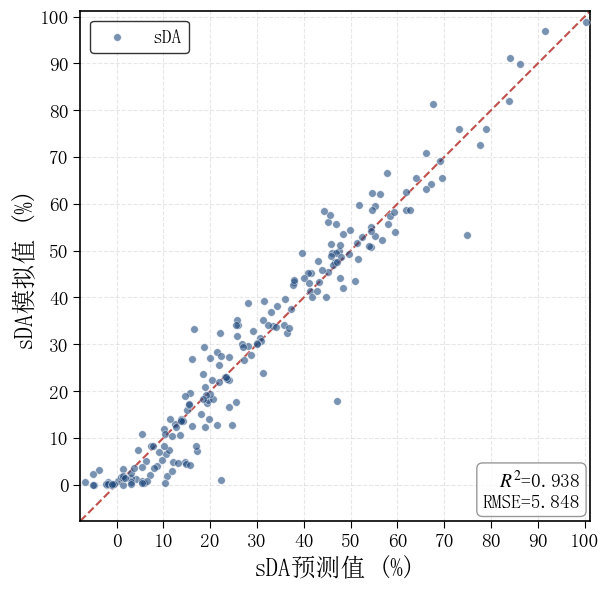

In [4]:
# ==================== 7. SCI 标准验证图（sDA）====================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['SimSun', 'DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['axes.linewidth'] = 1.2

fig, ax = plt.subplots(figsize=(7, 6))

color_u = '#1f497d'
line_color = '#c0504d'

ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

min_u, max_u = min(min(pred_u), min(y_test_u)) - 1, max(max(pred_u), max(y_test_u)) + 1

# ==================== 强制 x/y 刻度完全同步 ====================
import numpy as np
ticks = np.arange(0, 101, 10)  # sDA 范围 0-100，每 10 一条刻度
ax.set_xticks(ticks)
ax.set_yticks(ticks)
# ===================================================================

ax.scatter(pred_u, y_test_u, s=30, c=color_u, alpha=0.6, 
         edgecolors='white', linewidth=0.5, zorder=3)
ax.plot([min_u, max_u], [min_u, max_u], '--', color=line_color, 
        linewidth=1.5, zorder=2)

ax.set_xlabel('sDA预测值 (%)', fontsize=18, fontweight='bold')
ax.set_ylabel('sDA模拟值 (%)', fontsize=18, fontweight='bold')

ax.set_xlim(min_u, max_u)
ax.set_ylim(min_u, max_u)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.3)

ax.legend(['sDA',], loc='upper left', frameon=True, 
          edgecolor='black', fontsize=14)
ax.text(0.98, 0.02, f'$R^2$={r2_u:.3f}\nRMSE={rmse_u:.3f}', 
        transform=ax.transAxes, fontsize=14,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.savefig('s_XGBoost_sDA_Validation_cn.png', dpi=600, bbox_inches='tight')
plt.show()